# Single-Layer SPD-Lasso Graphs

This notebook generates 4 single-layer SPD-Lasso graphs with:
- RNA dataset: lambda = 0.2
- Histone datasets (k20me3, k9me2, k27me3): lambda = 0.3

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# Make sure the repository root is importable when running from different working directories.
candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
project_root = None
for candidate in candidates:
    if (candidate / "DiffusionRWR_model_package").exists():
        project_root = candidate
        break

if project_root is None:
    raise RuntimeError("Could not find project root containing DiffusionRWR_model_package")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from DiffusionRWR_model_package.data_sorting import load_data
from DiffusionRWR_model_package.graph_generation.generate_graph_internal import lasso_single_graph

print(f"Using project root: {project_root}")

Number of CSV files found: 4

CSV files found:
  - overlap_filtered_k20me3_m_v2.csv
  - overlap_filtered_k27me3_m_v2.csv
  - overlap_filtered_k9me2_m_v2.csv
  - overlap_filtered_rna_ai_m_v2.csv
  Filtered to integer time points: ['0', '1', '2', '3', '4']
Imported 'overlap_filtered_k20me3_m_v2' with shape: (657, 5) (row-wise standardized)
  Filtered to integer time points: ['0', '1', '2', '3', '4']
Imported 'overlap_filtered_k27me3_m_v2' with shape: (650, 5) (row-wise standardized)
  Filtered to integer time points: ['0', '1', '2', '3', '4']
Imported 'overlap_filtered_k9me2_m_v2' with shape: (1001, 5) (row-wise standardized)
  Filtered to integer time points: ['0', '1', '2', '3', '4']
Imported 'overlap_filtered_rna_ai_m_v2' with shape: (384, 5) (row-wise standardized)

Successfully imported 4 datasets.
Available datasets: ['overlap_filtered_k20me3_m_v2', 'overlap_filtered_k27me3_m_v2', 'overlap_filtered_k9me2_m_v2', 'overlap_filtered_rna_ai_m_v2']
Using project root: c:\Users\inigo\OneD

In [2]:
data_folder = project_root / "DiffusionRWR_model_package" / "data" / "Modelled"
datasets = load_data(data_folder)

def find_dataset_key(name_token):
    matches = sorted([k for k in datasets.keys() if name_token.lower() in k.lower()])
    if not matches:
        raise ValueError(f"Could not find dataset matching token: {name_token}")
    return matches[0]

dataset_map = {
    "rna_ai": find_dataset_key("rna"),
    "k20me3": find_dataset_key("k20me3"),
    "k9me2": find_dataset_key("k9me2"),
    "k27me3": find_dataset_key("k27me3"),
}

lambda_map = {
    "rna_ai": 0.2,
    "k20me3": 0.3,
    "k9me2": 0.3,
    "k27me3": 0.3,
}

# Set to None to visualize each entire graph (all nodes).
top_n_nodes = None
edge_threshold = 0.01
start_basis = "KSR2"
end_basis = "KSR2"

graph_pack = {}
std_data_selected = {}
shadow_intra_graphs = {}
shadow_sign_matrices = {}

for display_name in ["rna_ai", "k20me3", "k9me2", "k27me3"]:
    source_key = dataset_map[display_name]
    ds_one = {display_name: datasets[source_key]}
    std_data_selected[display_name] = datasets[source_key]

    adj_dict, sign_dict = lasso_single_graph(
        ds_one,
        edge_fn=None,
        start=start_basis,
        end=end_basis,
        return_signs=True,
        lasso_lambda=lambda_map[display_name],
    )

    adj = adj_dict[display_name].copy()
    sign = sign_dict[display_name].copy()

    # Apply a common threshold and keep sign only on surviving edges.
    adj[adj < edge_threshold] = 0.0
    sign = sign.where(adj > 0, other=0)

    out_degree = (adj > 0).sum(axis=1)
    in_degree = (adj > 0).sum(axis=0)
    total_degree = out_degree + in_degree

    if top_n_nodes is None or top_n_nodes <= 0 or top_n_nodes >= len(adj):
        selected_nodes = adj.index.tolist()
    else:
        selected_nodes = total_degree.nlargest(top_n_nodes).index.tolist()
        for basis in [start_basis, end_basis]:
            if basis in adj.index and basis not in selected_nodes:
                selected_nodes.append(basis)

    adj_sub = adj.loc[selected_nodes, selected_nodes]
    sign_sub = sign.loc[selected_nodes, selected_nodes]
    graph = nx.from_pandas_adjacency(adj_sub, create_using=nx.DiGraph)

    graph_pack[display_name] = {
        "lambda": lambda_map[display_name],
        "adjacency": adj_sub,
        "sign": sign_sub,
        "graph": graph,
    }

    # Keep full layer matrices for shadow digraph composition.
    shadow_intra_graphs[display_name] = adj
    shadow_sign_matrices[display_name] = sign

print("Prepared graphs:")
for name, pack in graph_pack.items():
    g = pack["graph"]
    print(f"  {name}: lambda={pack['lambda']}, nodes={g.number_of_nodes()}, edges={g.number_of_edges()}")

print("\nShadow-composition inputs ready:")
print(f"  layers: {list(shadow_intra_graphs.keys())}")
print(f"  threshold: {edge_threshold}")

Number of CSV files found: 4

CSV files found:
  - overlap_filtered_k20me3_m_v2.csv
  - overlap_filtered_k27me3_m_v2.csv
  - overlap_filtered_k9me2_m_v2.csv
  - overlap_filtered_rna_ai_m_v2.csv
  Filtered to integer time points: ['0', '1', '2', '3', '4']
Imported 'overlap_filtered_k20me3_m_v2' with shape: (657, 5) (row-wise standardized)
  Filtered to integer time points: ['0', '1', '2', '3', '4']
Imported 'overlap_filtered_k27me3_m_v2' with shape: (650, 5) (row-wise standardized)
  Filtered to integer time points: ['0', '1', '2', '3', '4']
Imported 'overlap_filtered_k9me2_m_v2' with shape: (1001, 5) (row-wise standardized)
  Filtered to integer time points: ['0', '1', '2', '3', '4']
Imported 'overlap_filtered_rna_ai_m_v2' with shape: (384, 5) (row-wise standardized)

Successfully imported 4 datasets.
Available datasets: ['overlap_filtered_k20me3_m_v2', 'overlap_filtered_k27me3_m_v2', 'overlap_filtered_k9me2_m_v2', 'overlap_filtered_rna_ai_m_v2']

Generating single-layer graph using SP

In [5]:
from DiffusionRWR_model_package.graph_generation.generate_multi_graph import create_shadow_network_multigraph
from DiffusionRWR_model_package.graph_generation.edge_weight_functions import cor_abs_inter
import pandas as pd

# Build combined shadow digraph adjacency from the four single-layer SPD-Lasso graphs.
shadow_adj = create_shadow_network_multigraph(
    std_data_dict=std_data_selected,
    intra_graphs=shadow_intra_graphs,
    sign_matrices=shadow_sign_matrices,
    edge_fn_inter=cor_abs_inter,
    gamma=0.5,
    alpha=0.5,
    start="KSR2",
    end="KSR2",
 )

# NOTE: Do not hard-threshold after normalization/composition.
# Thresholding is applied only pre-normalization in Cell 3.

# Persist artifacts so they are immediately reusable in later shadow-digraph steps.
output_dir = project_root / "outputs" / "spd_lasso_shadow_ready"
output_dir.mkdir(parents=True, exist_ok=True)

for layer_name in ["rna_ai", "k20me3", "k9me2", "k27me3"]:
    adj_df = shadow_intra_graphs[layer_name]
    sign_df = shadow_sign_matrices[layer_name]

    adj_df.to_csv(output_dir / f"{layer_name}_adjacency.csv")
    sign_df.to_csv(output_dir / f"{layer_name}_signs.csv")

    edge_rows = []
    nz = np.where(adj_df.to_numpy(dtype=float) > 0)
    row_names = adj_df.index.to_numpy()
    col_names = adj_df.columns.to_numpy()
    for i, j in zip(nz[0], nz[1]):
        edge_rows.append({
            "source": str(row_names[i]),
            "target": str(col_names[j]),
            "weight": float(adj_df.iat[i, j]),
            "sign": int(sign_df.iat[i, j]),
            "layer": layer_name,
        })
    edge_df = pd.DataFrame(edge_rows)
    edge_df.to_csv(output_dir / f"{layer_name}_edge_list.csv", index=False)

shadow_adj.to_csv(output_dir / "shadow_combined_adjacency.csv")

shadow_graph = nx.from_pandas_adjacency(shadow_adj, create_using=nx.DiGraph)
print("Shadow digraph ready.")
print(f"  Nodes: {shadow_graph.number_of_nodes()}")
print(f"  Edges: {shadow_graph.number_of_edges()}")
print("  Hard thresholding: pre-normalization only (Cell 3)")
print(f"  Saved to: {output_dir}")

CREATING SHADOW NETWORK (BLOCKWISE CONSTRUCTION)
Building normalized regular multigraph, then applying sign masks blockwise
Note: gamma=0.5 is ignored in dynamic-shadow mode
Alpha (inter-layer transition probability): 0.5
Intra-layer probability: 0.5

[STEP 1] Building normalized regular multigraph...
CREATING MULTI-LAYER GRAPH WITH LAYER TRANSITIONS
Alpha (inter-layer transition probability): 0.5
Intra-layer probability: 0.5
CREATING MULTI-LAYER GRAPH

[STEP 1] Intra layer graphs are generated separately and provided as input (skipping generation here)

[STEP 2] Generating inter-layer connections...

  Connecting rna_ai -> k20me3
    Section shape: (384, 657)

  Connecting rna_ai -> k9me2
    Section shape: (384, 1001)

  Connecting rna_ai -> k27me3
    Section shape: (384, 650)

  Connecting k20me3 -> k9me2
    Section shape: (657, 1001)

  Connecting k20me3 -> k27me3
    Section shape: (657, 650)

  Connecting k9me2 -> k27me3
    Section shape: (1001, 650)

[STEP 3] Assembling compl

Top 15 nodes by PageRank (original graph: sinks/receivers):


,node,pagerank_sink,pagerank_source
0,e1,0.001470,0.000124
1,e2,0.000977,0.000118
2,SHOX2_rna_ai_neg,0.000976,0.000206
3,SHOX2_rna_ai,0.000971,0.000206
4,FMNL2*2_k20me3_neg,0.000945,0.000244
5,FMNL2*2_k20me3,0.000940,0.000244
6,TMEM164_rna_ai,0.000712,0.000220
7,GRIK2_rna_ai_neg,0.000701,0.000179
8,TMEM164_rna_ai_neg,0.000701,0.000220
9,GRIK2_rna_ai,0.000687,0.000180


Top 15 nodes by PageRank on transposed adjacency (sources/broadcasters):


,node,pagerank_sink,pagerank_source
3763,GAB2*8_k9me2,0.000142,0.000301
3714,GAB2*8_k9me2_neg,0.000143,0.000301
1963,OXER1_k9me2_neg,0.000188,0.000286
1801,OXER1_k9me2,0.000195,0.000286
231,KIF16B*8_k20me3,0.000335,0.000283
229,KIF16B*8_k20me3_neg,0.000336,0.000283
671,DPP4*16_k20me3,0.000261,0.000275
536,DPP4*16_k20me3_neg,0.000276,0.000274
4551,GNPAT_k9me2_neg,0.000126,0.000273
4287,GNPAT_k9me2,0.000132,0.000272


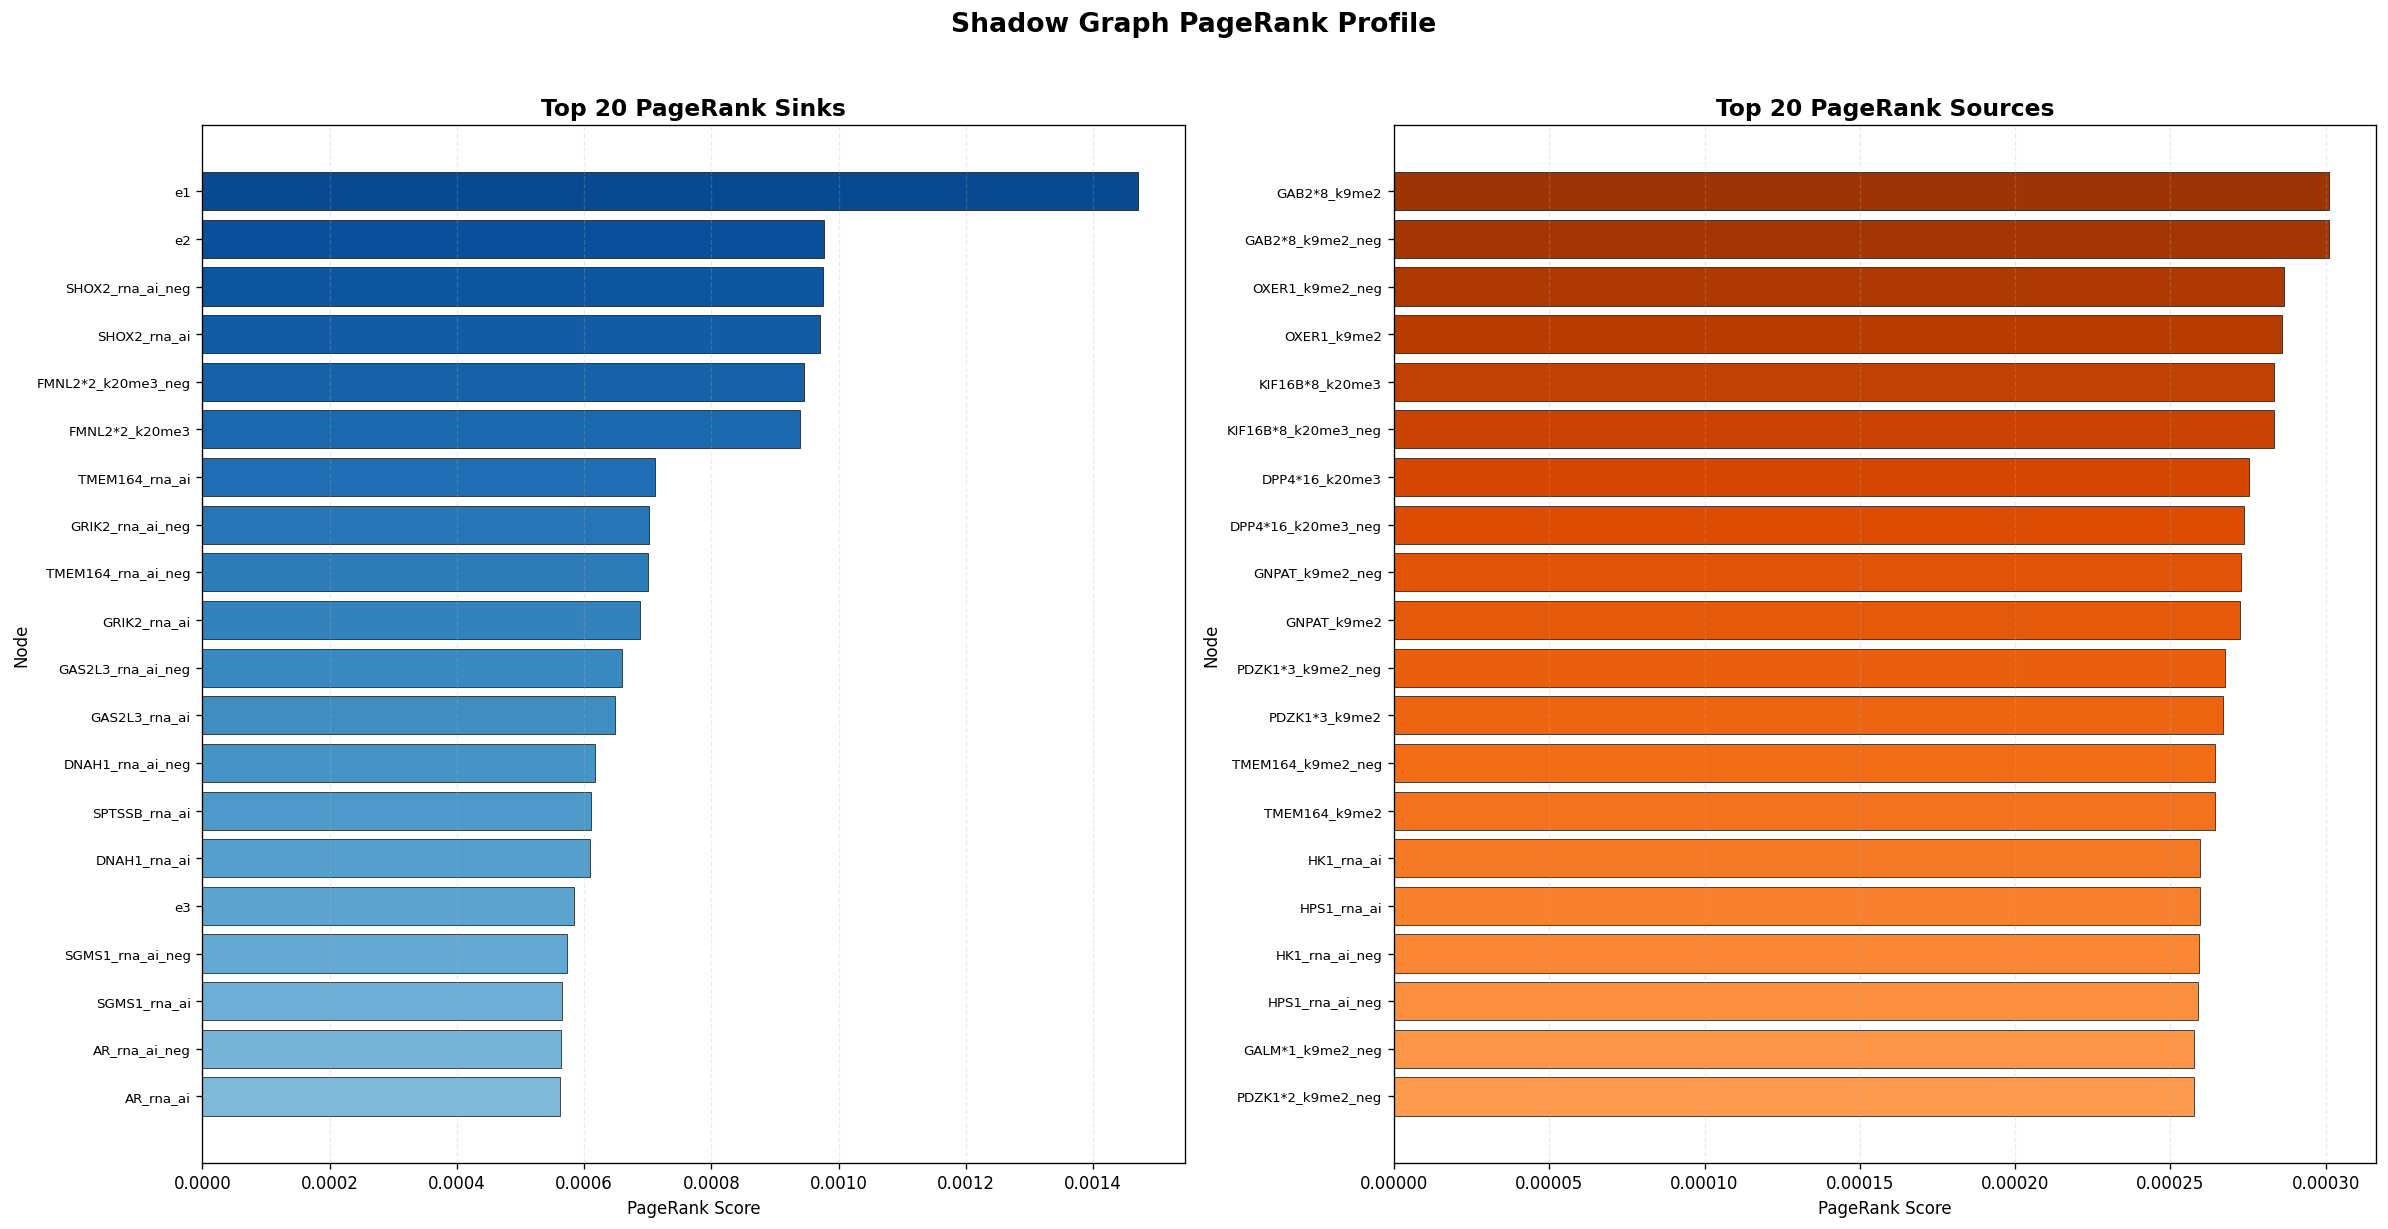

Saved centrality table to: c:\Users\inigo\OneDrive\Documents\Fourth_Year\Computations\Dissertation\DiffusionRWR_model_repo\outputs\spd_lasso_shadow_ready\shadow_graph_centrality.csv
Saved PageRank bar chart to: c:\Users\inigo\OneDrive\Documents\Fourth_Year\Computations\Dissertation\DiffusionRWR_model_repo\outputs\spd_lasso_shadow_ready\shadow_graph_pagerank_barplot.png


In [4]:
# Compute PageRank centrality on the shadow multigraph and visualize the top-ranked nodes.
if "shadow_graph" not in globals():
    raise RuntimeError("Run Cell 4 first to build shadow_graph.")

import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

# PageRank on original graph (information sinks / receivers).
pagerank_scores = nx.pagerank(shadow_graph, alpha=0.85, weight="weight", max_iter=300)

# PageRank on transposed adjacency (information sources / broadcasters).
if "shadow_adj" in globals():
    shadow_graph_T = nx.from_pandas_adjacency(shadow_adj.T, create_using=nx.DiGraph)
else:
    shadow_graph_T = shadow_graph.reverse(copy=True)

pagerank_source_scores = nx.pagerank(shadow_graph_T, alpha=0.85, weight="weight", max_iter=300)

centrality_df = pd.DataFrame({
    "node": list(shadow_graph.nodes()),
    "pagerank_sink": [pagerank_scores[n] for n in shadow_graph.nodes()],
    "pagerank_source": [pagerank_source_scores[n] for n in shadow_graph.nodes()],
}).sort_values("pagerank_sink", ascending=False).reset_index(drop=True)

print("Top 15 nodes by PageRank (original graph: sinks/receivers):")
display(centrality_df.sort_values("pagerank_sink", ascending=False).head(15))

print("Top 15 nodes by PageRank on transposed adjacency (sources/broadcasters):")
display(centrality_df.sort_values("pagerank_source", ascending=False).head(15))

# Build a clear side-by-side PageRank visualization.
plot_top_n = 20
sink_top = centrality_df.nlargest(plot_top_n, "pagerank_sink").sort_values("pagerank_sink", ascending=True)
source_top = centrality_df.nlargest(plot_top_n, "pagerank_source").sort_values("pagerank_source", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(20, 10), dpi=120)

sink_colors = plt.cm.Blues(np.linspace(0.45, 0.9, len(sink_top)))
source_colors = plt.cm.Oranges(np.linspace(0.45, 0.9, len(source_top)))

axes[0].barh(sink_top["node"], sink_top["pagerank_sink"], color=sink_colors, edgecolor="black", linewidth=0.4)
axes[0].set_title(f"Top {plot_top_n} PageRank Sinks", fontsize=14, fontweight="bold")
axes[0].set_xlabel("PageRank Score")
axes[0].set_ylabel("Node")
axes[0].grid(axis="x", alpha=0.25, linestyle="--")

axes[1].barh(source_top["node"], source_top["pagerank_source"], color=source_colors, edgecolor="black", linewidth=0.4)
axes[1].set_title(f"Top {plot_top_n} PageRank Sources", fontsize=14, fontweight="bold")
axes[1].set_xlabel("PageRank Score")
axes[1].set_ylabel("Node")
axes[1].grid(axis="x", alpha=0.25, linestyle="--")

for ax in axes:
    ax.tick_params(axis="y", labelsize=8)

plt.suptitle("Shadow Graph PageRank Profile", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()

if "output_dir" not in globals():
    output_dir = project_root / "outputs" / "spd_lasso_shadow_ready"
    output_dir.mkdir(parents=True, exist_ok=True)

pagerank_plot_path = output_dir / "shadow_graph_pagerank_barplot.png"
fig.savefig(pagerank_plot_path, dpi=200, bbox_inches="tight")
plt.show()

centrality_df.to_csv(output_dir / "shadow_graph_centrality.csv", index=False)
print(f"Saved centrality table to: {output_dir / 'shadow_graph_centrality.csv'}")
print(f"Saved PageRank bar chart to: {pagerank_plot_path}")

In [ ]:
# Calculate nearby nodes to each 